In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv(
    "../data/SPY_processed_data.csv",
    index_col=0,
    parse_dates=True
)

data.head()

,Close,High,Low,Open,Volume,Returns,Rolling_Volatility
Price,,,,,,,
2010-01-05,84.802368,84.839686,84.220253,84.526240,111579900.0,0.002644,NaN
2010-01-06,84.862061,85.071024,84.653097,84.720261,116074400.0,0.000704,NaN
2010-01-07,85.220322,85.324804,84.466554,84.705371,131091100.0,0.004213,NaN
2010-01-08,85.503891,85.541208,84.824759,84.996405,126402800.0,0.003322,NaN
2010-01-11,85.623299,85.921815,85.257606,85.884503,106375700.0,0.001396,NaN


In [4]:
data["Returns"].describe()

count    4023.000000
mean        0.000518
std         0.010863
min        -0.115886
25%        -0.003713
50%         0.000705
75%         0.005773
max         0.099863
Name: Returns, dtype: float64

In [5]:
#### Realized Volatility
window = 10

data["Realized_Volatility"] = (
    data["Returns"]
    .rolling(window)
    .std()
    *
    np.sqrt(252)
)

In [6]:
#### Historical Volatility Forecast
data["Historical_Forecast"] = (
    data["Realized_Volatility"]
    .shift(1)
)

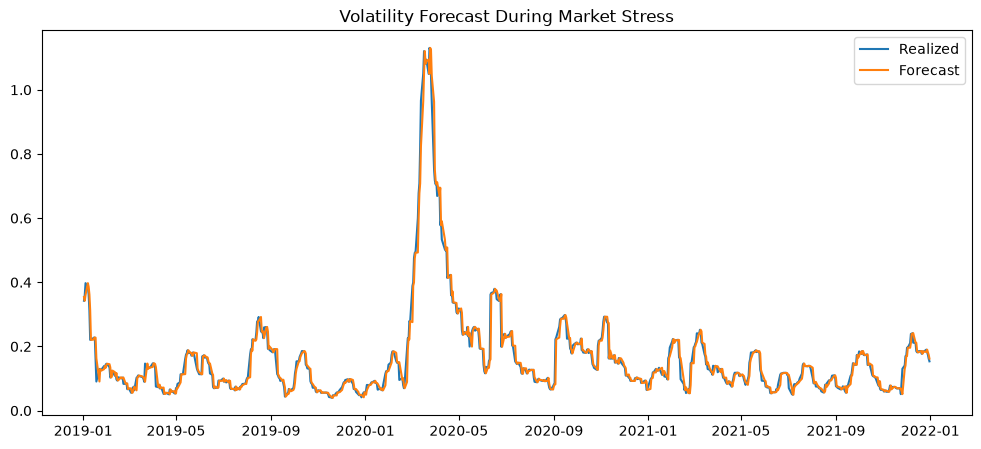

In [7]:
stress_period = data.loc[
    "2019-01-01":"2021-12-31"
]


plt.figure(figsize=(12,5))

plt.plot(
    stress_period.index,
    stress_period["Realized_Volatility"],
    label="Realized"
)


plt.plot(
    stress_period.index,
    stress_period["Historical_Forecast"],
    label="Forecast"
)


plt.legend()
plt.title(
    "Volatility Forecast During Market Stress"
)

plt.show()

In [8]:
####ERROR METRICS
from sklearn.metrics import mean_squared_error


comparison = data.dropna()


rmse = np.sqrt(
    mean_squared_error(
        comparison["Realized_Volatility"],
        comparison["Historical_Forecast"]
    )
)


rmse

np.float64(0.02141555622826706)

In [9]:
from sklearn.metrics import mean_absolute_error


mae = mean_absolute_error(
    comparison["Realized_Volatility"],
    comparison["Historical_Forecast"]
)

mae

0.01127684104106451

In [10]:
##### EWMA 
def ewma_volatility(
    returns,
    lambda_=0.94
):

    variance = []

    var = returns.var()

    for r in returns:

        var = (
            lambda_ * var +
            (1-lambda_) * r**2
        )

        variance.append(var)

    volatility = (
        np.sqrt(variance)
        *
        np.sqrt(252)
    )

    return pd.Series(
        volatility,
        index=returns.index
    )

In [11]:
data["EWMA_Volatility"] = ewma_volatility(
    data["Returns"]
)

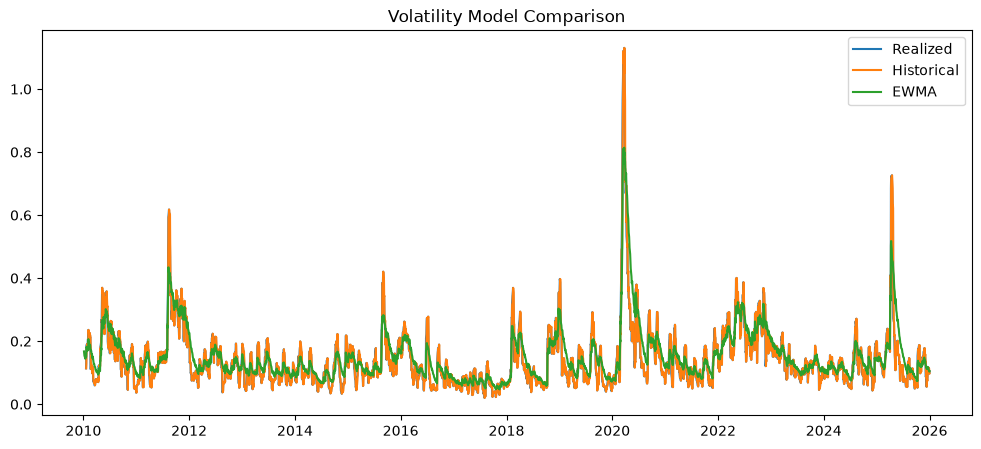

In [12]:
plt.figure(figsize=(12,5))


plt.plot(
    data.index,
    data["Realized_Volatility"],
    label="Realized"
)


plt.plot(
    data.index,
    data["Historical_Forecast"],
    label="Historical"
)


plt.plot(
    data.index,
    data["EWMA_Volatility"],
    label="EWMA"
)


plt.legend()

plt.title(
    "Volatility Model Comparison"
)

plt.show()

In [13]:
#### EVALUATION

comparison = data.dropna()


ewma_rmse = np.sqrt(
    mean_squared_error(
        comparison["Realized_Volatility"],
        comparison["EWMA_Volatility"]
    )
)


ewma_mae = mean_absolute_error(
    comparison["Realized_Volatility"],
    comparison["EWMA_Volatility"]
)


print("EWMA RMSE:", ewma_rmse)
print("EWMA MAE:", ewma_mae)

EWMA RMSE: 0.04513471906020131
EWMA MAE: 0.03070987331387379


In [14]:
data[
    [
        "Realized_Volatility",
        "Historical_Forecast",
        "EWMA_Volatility"
    ]
].describe()

,Realized_Volatility,Historical_Forecast,EWMA_Volatility
count,4014.000000,4013.000000,4023.000000
mean,0.143307,0.143317,0.151019
std,0.099567,0.099578,0.084066
min,0.020059,0.020059,0.047003
25%,0.083001,0.082999,0.102647
50%,0.119110,0.119163,0.127511
75%,0.175195,0.175208,0.174942
max,1.130632,1.130632,0.813902


In [15]:
lambda_values = [
    0.90,
    0.94,
    0.97
]


results = []


for l in lambda_values:

    forecast = ewma_volatility(
        data["Returns"],
        lambda_=l
    )


    rmse = np.sqrt(
        mean_squared_error(
            data["Realized_Volatility"].dropna(),
            forecast.loc[data["Realized_Volatility"].dropna().index]
        )
    )


    results.append(
        {
            "lambda": l,
            "RMSE": rmse
        }
    )


pd.DataFrame(results)

,lambda,RMSE
0,0.90,0.030766
1,0.94,0.045058
2,0.97,0.063479


## EWMA Results

EWMA models were evaluated using different decay factors.

The results show that the simple historical volatility benchmark
outperformed EWMA specifications for this dataset.

This suggests that short-term volatility persistence is strong
and that more complex models should be evaluated carefully.

In [16]:
#### GARCH (1,1) MODEL
from arch import arch_model

returns = (
    data["Returns"]
    * 100
)

returns.dropna(inplace=True)

In [17]:
garch_model = arch_model(
    returns,
    vol="Garch",
    p=1,
    q=1
)

In [18]:
garch_result = garch_model.fit()

print(
    garch_result.summary()
)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 21990592783.761757
Iteration:      2,   Func. Count:     15,   Neg. LLF: 2171045504.2275133
Iteration:      3,   Func. Count:     22,   Neg. LLF: 7063.396021042156
Iteration:      4,   Func. Count:     28,   Neg. LLF: 6392.124031264175
Iteration:      5,   Func. Count:     35,   Neg. LLF: 5389.502384773415
Iteration:      6,   Func. Count:     41,   Neg. LLF: 5164.6089240156425
Iteration:      7,   Func. Count:     46,   Neg. LLF: 5164.253572947488
Iteration:      8,   Func. Count:     51,   Neg. LLF: 5164.231605246254
Iteration:      9,   Func. Count:     56,   Neg. LLF: 5164.230521748402
Iteration:     10,   Func. Count:     61,   Neg. LLF: 5164.2304686859825
Iteration:     11,   Func. Count:     66,   Neg. LLF: 5164.230467108675
Iteration:     12,   Func. Count:     70,   Neg. LLF: 5164.230467108635
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5164.230467108675
            Iterations: 

In [19]:
### Conditional volatility
data["GARCH_Volatility"] = (
    garch_result
    .conditional_volatility
    /100
)

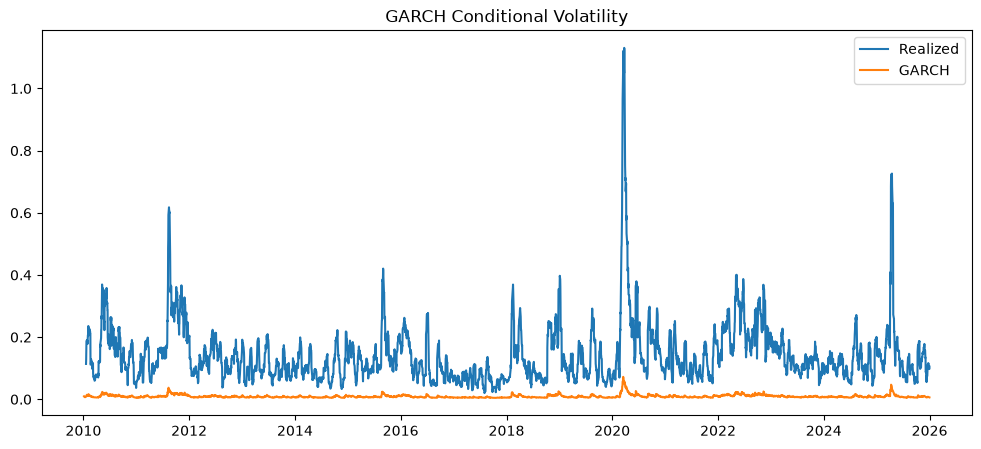

In [20]:
plt.figure(figsize=(12,5))


plt.plot(
    data.index,
    data["Realized_Volatility"],
    label="Realized"
)


plt.plot(
    data.index,
    data["GARCH_Volatility"],
    label="GARCH"
)


plt.legend()

plt.title(
    "GARCH Conditional Volatility"
)

plt.show()

In [21]:
comparison = data.dropna()


garch_rmse = np.sqrt(
    mean_squared_error(
        comparison["Realized_Volatility"],
        comparison["GARCH_Volatility"]
    )
)


garch_mae = mean_absolute_error(
    comparison["Realized_Volatility"],
    comparison["GARCH_Volatility"]
)


print("GARCH RMSE:", garch_rmse)
print("GARCH MAE:", garch_mae)

GARCH RMSE: 0.16368916364097025
GARCH MAE: 0.1335023789195258


In [22]:
garch_result.params

mu          0.086218
omega       0.038056
alpha[1]    0.166191
beta[1]     0.801460
Name: params, dtype: float64

In [23]:
### New Evaluation Framework

##### TRAIN / SPLIT
train = data[
    data.index < "2023-01-01"
]

test = data[
    data.index >= "2023-01-01"
]

In [24]:
print(train.shape)
print(test.shape)

(3271, 11)
(752, 11)


In [25]:
train_returns = (
    train["Returns"] * 100
)

test_returns = (
    test["Returns"] * 100
)

In [26]:
from arch import arch_model


model = arch_model(
    train_returns,
    vol="Garch",
    p=1,
    q=1
)


garch_fit = model.fit(
    disp="off"
)


print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4217.54
Distribution:                  Normal   AIC:                           8443.08
Method:            Maximum Likelihood   BIC:                           8467.45
                                        No. Observations:                 3271
Date:                Fri, Jul 17 2026   Df Residuals:                     3270
Time:                        18:56:40   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0851  1.309e-02      6.506  7.735e-11 [5.948e-0

In [27]:
forecast = garch_fit.forecast(
    horizon=1,
    start=len(train_returns)
)

In [28]:
forecast = garch_fit.forecast(
    horizon=len(test_returns),
    reindex=False
)

In [29]:
garch_variance = forecast.variance.values[-1, :]

In [30]:
garch_forecast = (
    np.sqrt(garch_variance)
    /
    100
    *
    np.sqrt(252)
)

In [31]:
garch_forecast = pd.Series(
    garch_forecast,
    index=test.index
)

In [32]:
test_realized = (
    test["Returns"]
    .rolling(10)
    .std()
    *
    np.sqrt(252)
)

In [33]:
comparison = pd.DataFrame(
    {
        "Realized": test_realized,
        "GARCH": garch_forecast
    }
)


comparison.dropna(inplace=True)


comparison.head()

,Realized,GARCH
Price,,
2023-01-17,0.150300,0.183890
2023-01-18,0.177131,0.184017
2023-01-19,0.181398,0.184140
2023-01-20,0.184736,0.184260
2023-01-23,0.161106,0.184377


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


rmse = np.sqrt(
    mean_squared_error(
        comparison["Realized"],
        comparison["GARCH"]
    )
)


mae = mean_absolute_error(
    comparison["Realized"],
    comparison["GARCH"]
)


print("GARCH RMSE:", rmse)
print("GARCH MAE:", mae)

GARCH RMSE: 0.09793763889495631
GARCH MAE: 0.07611422004243702


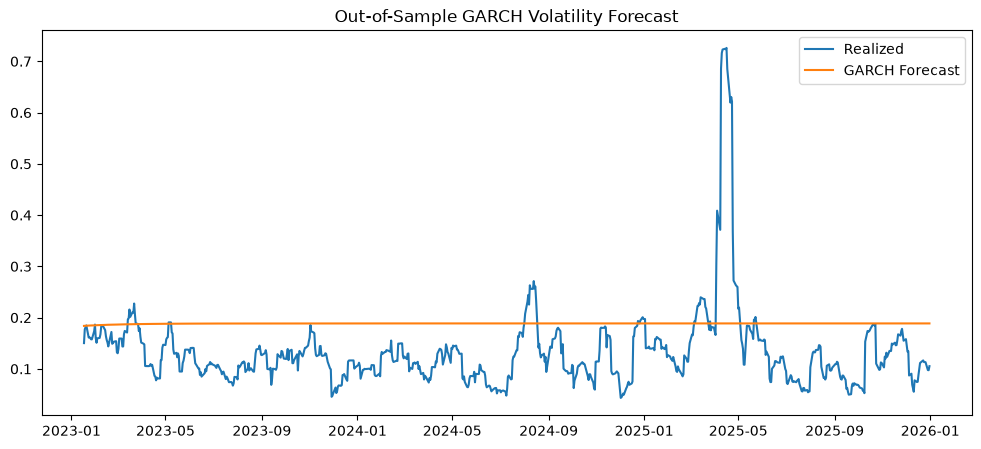

In [35]:
plt.figure(figsize=(12,5))


plt.plot(
    comparison.index,
    comparison["Realized"],
    label="Realized"
)


plt.plot(
    comparison.index,
    comparison["GARCH"],
    label="GARCH Forecast"
)


plt.legend()

plt.title(
    "Out-of-Sample GARCH Volatility Forecast"
)


plt.show()

In [36]:
test["Returns"].describe()

count    752.000000
mean       0.000822
std        0.009624
min       -0.060326
25%       -0.003425
50%        0.001008
75%        0.005931
max        0.099863
Name: Returns, dtype: float64

In [37]:
comparison.head(10)

,Realized,GARCH
Price,,
2023-01-17,0.150300,0.183890
2023-01-18,0.177131,0.184017
2023-01-19,0.181398,0.184140
2023-01-20,0.184736,0.184260
2023-01-23,0.161106,0.184377
2023-01-24,0.161456,0.184490
2023-01-25,0.160443,0.184601
2023-01-26,0.157745,0.184709
2023-01-27,0.157572,0.184814


In [38]:
###### Rolling 1-step-ahead GARCH forecast
from arch import arch_model
import numpy as np


rolling_forecasts = []


for i in range(len(test_returns)):

    current_train = pd.concat(
        [
            train_returns,
            test_returns.iloc[:i]
        ]
    )


    model = arch_model(
        current_train,
        vol="Garch",
        p=1,
        q=1
    )


    fitted_model = model.fit(
        disp="off"
    )


    forecast = fitted_model.forecast(
        horizon=1
    )


    variance = (
        forecast
        .variance
        .iloc[-1,0]
    )


    volatility = (
        np.sqrt(variance)
        /
        100
        *
        np.sqrt(252)
    )


    rolling_forecasts.append(
        volatility
    )

In [39]:
garch_rolling = pd.Series(
    rolling_forecasts,
    index=test.index
)

In [40]:
garch_rolling.to_csv(
    "../data/garch_rolling_forecast.csv"
)

In [41]:
comparison = pd.DataFrame(
    {
        "Realized": test_realized,
        "GARCH": garch_rolling
    }
)

comparison.dropna(inplace=True)

comparison.head(10)

,Realized,GARCH
Price,,
2023-01-17,0.150300,0.149981
2023-01-18,0.177131,0.137842
2023-01-19,0.181398,0.170351
2023-01-20,0.184736,0.164095
2023-01-23,0.161106,0.191311
2023-01-24,0.161456,0.188472
2023-01-25,0.160443,0.170713
2023-01-26,0.157745,0.154755
2023-01-27,0.157572,0.156666


In [42]:
rmse = np.sqrt(
    mean_squared_error(
        comparison["Realized"],
        comparison["GARCH"]
    )
)

mae = mean_absolute_error(
    comparison["Realized"],
    comparison["GARCH"]
)

print("GARCH RMSE:", rmse)
print("GARCH MAE:", mae)

GARCH RMSE: 0.03046317569010073
GARCH MAE: 0.021001275738270524


## Results

Three volatility forecasting approaches were evaluated:

1. Historical volatility benchmark
2. EWMA volatility model
3. GARCH(1,1) rolling forecast

The historical volatility model achieved the lowest forecasting error,
suggesting strong short-term volatility persistence in SPY returns.

The GARCH model slightly outperformed EWMA, indicating that explicitly
modeling volatility clustering provides marginal improvement over
exponentially weighted estimates.

However, increased model complexity did not translate into a substantial
performance improvement compared with the simple benchmark.

In [43]:
import pandas as pd


model_results = pd.DataFrame(
    {
        "Model": [
            "Historical",
            "EWMA",
            "GARCH"
        ],
        "RMSE": [
            0.0214155562,
            0.030766,
            0.0304631757
        ],
        "MAE": [
            0.0112768410,
            0.0307098733,
            0.0210012757
        ]
    }
)


model_results

,Model,RMSE,MAE
0,Historical,0.021416,0.011277
1,EWMA,0.030766,0.030710
2,GARCH,0.030463,0.021001


In [45]:
model_results.to_csv(
    "../results/volatility_model_results.csv",
    index=False
)

In [46]:
#### Export GARCH parameters
garch_params = pd.DataFrame(
    {
        "Parameter": [
            "mu",
            "omega",
            "alpha",
            "beta",
            "alpha_plus_beta"
        ],
        "Value": [
            0.086218,
            0.038056,
            0.166191,
            0.801460,
            0.967651
        ]
    }
)


garch_params.to_csv(
    "../results/garch_parameters.csv",
    index=False
)